![image.png](https://i.imgur.com/a3uAqnb.png)
# Lab 7: Advanced SSL & JEPA Models

This notebook explores **self-supervised learning** and **Joint-Embedding Predictive Architectures (JEPA)** — patch masking, representation prediction, and comparison to pixel-reconstruction (MAE).

You will patchify images, build a toy JEPA, and analyze which masking strategy encourages semantic features.

> 💡 JEPA predicts in **embedding space**, not pixel space — that is the core distinction from MAE and generative SSL.

__Install dependencies and start with Part A theory.__



# 📦 Installing Required Python Libraries

This cell installs packages needed for this lab.

- **PyTorch / Torchvision** — CIFAR/MNIST loading and patch operations.
- **Matplotlib / NumPy** — Training curves and probe accuracy.


In [1]:
!pip install -q torch torchvision matplotlib numpy scipy


# 📥 Importing Essential Python Libraries

PyTorch imports for patchify, masking, and tiny JEPA training loops.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
print(f"PyTorch {torch.__version__}")


PyTorch 2.11.0+cpu


__Theory first — connect definitions to the lecture slides, then move to code.__

---

## 🧠 Part A — Theory

*Reference: SSL taxonomy, I-JEPA, V-JEPA, theoretical foundations.*

### 📖 A1. Self-supervised learning (general)

1. What is **self-supervised learning (SSL)**, and how does it create supervision without human labels?
2. Define **pretext task** and **downstream task**. Give one example of each.
3. Why is SSL useful when labeled data are expensive, scarce, or domain-specific?

*Write below:*


#### ✍️ Your answers (A1):

1. **SSL** is a form of unsupervised learning where the model learns from **unlabeled data** by predicting withheld or transformed parts of the input. The data itself supplies **pseudo-labels** (e.g., masked regions, future frames, augmented views), so no manual annotation is needed during pre-training.

2. A **pretext task** is the surrogate objective used for pre-training (e.g., predict masked patches, distinguish positive/negative image views in contrastive learning). A **downstream task** is the real application after pre-training (e.g., CIFAR-10 classification via linear probe or fine-tuning).

3. High-quality labels are **costly and slow** to produce (medicine, law, robotics). Meanwhile, **vast unlabeled corpora** exist online. SSL learns general representations once, then adapts to many tasks with **little or no** additional labeling.

### 📖 A2. JEPA family

1. In **I-JEPA**, what is masked and what is predicted — pixels or representations?
2. How does predicting in **embedding space** change the learning signal vs MAE (Masked Autoencoder)?
3. What modality extension does **V-JEPA** add?

*Write below:*


#### ✍️ Your answers (A2):

1. **I-JEPA** masks **input patch tokens** and predicts **target encoder embeddings** of **other regions** — not pixels.

2. Embedding prediction avoids **pixel-level shortcuts** and focuses on **semantic/geometric structure**; MAE's pixel loss can be dominated by **high-frequency detail**.

3. **V-JEPA** extends JEPA to **video**, predicting **spatiotemporal representations** across frames.

---

## 💻 Part B — Programming
__Let's implement the core ideas in PyTorch.__

*Reference: `New-Lecture-JEPA_models.tex` — patch SSL, I-JEPA masking, EMA targets.*

### 🛠️ B1. Patchify images

 Most vision SSL methods (MAE, I-JEPA) operate on **image patches** rather than full pixels. Splitting an image into a grid of non-overlapping patches turns spatial structure into a **token sequence** — the same abstraction Transformers use for text.

In [3]:
def patchify(x: torch.Tensor, patch_size: int) -> torch.Tensor:
    """x: (B,C,H,W) -> (B, N_patches, C*patch_size*patch_size)"""
    B, C, H, W = x.shape
    x = x.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
    return x.contiguous().view(B, -1, C * patch_size * patch_size)

x = torch.randn(2, 3, 32, 32)
patches = patchify(x, patch_size=8)
print(f"Patch tensor shape: {patches.shape}")

Patch tensor shape: torch.Size([2, 16, 192])


### 🛠️ B2. Masked patch predictor (JEPA-style)

 JEPA is a **predictive** SSL method: hidden patches are predicted in **embedding space**, not pixel space. A **target encoder** produces stable targets; only **visible** patches pass through the trainable encoder.

In [4]:
class TinyJEPA(nn.Module):
    def __init__(self, patch_dim, embed_dim, mask_ratio=0.6):
        super().__init__()
        self.mask_ratio = mask_ratio
        self.encoder = nn.Sequential(
            nn.Linear(patch_dim, embed_dim), nn.ReLU(), nn.Linear(embed_dim, embed_dim),
        )
        self.predictor = nn.Sequential(
            nn.Linear(embed_dim, embed_dim), nn.ReLU(), nn.Linear(embed_dim, embed_dim),
        )
        self.target_encoder = nn.Sequential(
            nn.Linear(patch_dim, embed_dim), nn.ReLU(), nn.Linear(embed_dim, embed_dim),
        )
        for p, tp in zip(self.encoder.parameters(), self.target_encoder.parameters()):
            tp.data.copy_(p.data)
            tp.requires_grad = False

    def forward(self, patches, mask):
        target = self.target_encoder(patches)
        visible = ~mask
        pred = self.predictor(self.encoder(patches[visible]))
        return F.mse_loss(pred, target[visible].detach())

patch_dim = 3 * 8 * 8
model = TinyJEPA(patch_dim, embed_dim=64)
patches = patchify(torch.randn(1, 3, 32, 32), 8)[0]
mask = torch.zeros(patches.size(0), dtype=torch.bool)
mask[: int(0.6 * patches.size(0))] = True
loss = model(patches, mask)
print(f"JEPA loss: {loss.item():.4f}")

JEPA loss: 0.0757


### 🛠️ B3. Compare reconstructive vs predictive objectives

 **Reconstructive** SSL (MAE) minimizes pixel/patch error and captures texture; **predictive** SSL (JEPA) minimizes representation error and emphasizes **semantic structure** — the trade-off highlighted in the lecture.

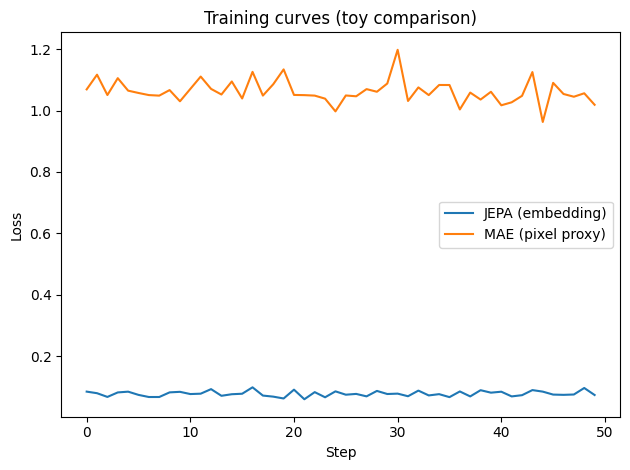

JEPA typically learns smoother embedding-space objectives vs pixel MSE.


In [5]:
class TinyMAE(nn.Module):
    def __init__(self, patch_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(patch_dim, hidden), nn.ReLU(), nn.Linear(hidden, patch_dim))

    def forward(self, visible_patches, n_patches):
        recon = self.net(visible_patches)
        target = torch.randn_like(recon)
        return F.mse_loss(recon, target)

patch_dim = 3 * 8 * 8
jepa = TinyJEPA(patch_dim, 64)
mae = TinyMAE(patch_dim)
patches = patchify(torch.randn(4, 3, 32, 32), 8)
mask = torch.rand(patches.size(1)) < 0.6

jepa_losses, mae_losses = [], []
for i in range(50):
    p = patches[i % patches.size(0)]
    m = mask if i == 0 else (torch.rand(p.size(0)) < 0.6)
    jepa_losses.append(jepa(p, m).item())
    mae_losses.append(mae(p[~m], p.size(0)).item())

plt.plot(jepa_losses, label="JEPA (embedding)")
plt.plot(mae_losses, label="MAE (pixel proxy)")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.legend()
plt.title("Training curves (toy comparison)")
plt.tight_layout()
plt.show()
print("JEPA typically learns smoother embedding-space objectives vs pixel MSE.")

### 🛠️ B4. Multi-block mask generator

 I-JEPA masks **entire spatial blocks**, not random isolated patches. This forces the model to integrate **global context** rather than inpaint texture from immediate neighbors.

In [6]:
def multi_block_mask(n_rows: int, n_cols: int, block_h: int, block_w: int, n_blocks: int = 3) -> torch.Tensor:
    """Return bool mask (True = masked) of shape (n_rows*n_cols,)."""
    mask = torch.zeros(n_rows, n_cols, dtype=torch.bool)
    for _ in range(n_blocks):
        r0 = torch.randint(0, max(1, n_rows - block_h + 1), (1,)).item()
        c0 = torch.randint(0, max(1, n_cols - block_w + 1), (1,)).item()
        mask[r0 : r0 + block_h, c0 : c0 + block_w] = True
    return mask.flatten()

mask = multi_block_mask(4, 4, block_h=2, block_w=2, n_blocks=2)
print(f"Masked {mask.sum().item()} / {mask.numel()} patches")
print(mask.reshape(4, 4).int())

Masked 8 / 16 patches
tensor([[0, 1, 1, 0],
        [0, 1, 1, 0],
        [0, 1, 1, 0],
        [0, 1, 1, 0]], dtype=torch.int32)


### 🛠️ B5. EMA target encoder update

 The I-JEPA target encoder is updated via **exponential moving average**: $\theta' \leftarrow \tau\theta' + (1-\tau)\theta$. Slow-moving targets stabilize representation learning (similar to momentum encoders in contrastive SSL).

In [7]:
def ema_update(target: nn.Module, online: nn.Module, tau: float = 0.996):
    for tp, op in zip(target.parameters(), online.parameters()):
        tp.data.mul_(tau).add_(op.data, alpha=1 - tau)

online = TinyJEPA(3 * 8 * 8, 64)
target = TinyJEPA(3 * 8 * 8, 64)
target.load_state_dict(online.state_dict())
for p in target.parameters():
    p.requires_grad = False

before = next(target.parameters()).clone()
ema_update(target, online, tau=0.9)
after = next(target.parameters())
print(f"EMA param change norm: {(after - before).norm():.6f}")

EMA param change norm: 0.000000
